# 🫁 Chest X-Ray Pneumonia Detection — Custom CNN vs. Transfer Learning

End-to-end **binary image classification** (NORMAL vs PNEUMONIA) designed to run
top-to-bottom on **Kaggle Notebooks (GPU P100)** — just press *Run All*.

**Clinical framing.** A missed pneumonia case (a *False Negative*) is more
dangerous than a false alarm, so **Recall / Sensitivity is the primary metric**
and **F1** is secondary.

**Pipeline.**
`EDA → Data prep (rebuilt validation split + class weights) → Custom CNN →
VGG16 transfer learning → Evaluation → Comparison → Grad-CAM → Conclusions`

All artifacts (trained `.keras` models and every figure) are written to
`/kaggle/working/`.

## 1 · Setup & Imports

Import everything, **fix all random seeds to 42** (Python, NumPy, TensorFlow) for
reproducibility, and configure the GPU. We enable *memory growth* so TensorFlow
allocates VRAM on demand instead of grabbing the whole card up front.

In [17]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,
                                      MaxPooling2D, GlobalAveragePooling2D,
                                      Dense, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.applications import VGG16

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

# ---------------------------------------------------------------------------
# Reproducibility: a single SEED feeds every random operation in the notebook.
# ---------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ---------------------------------------------------------------------------
# GPU configuration.
# ---------------------------------------------------------------------------
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
    print(f"GPU detected: {len(gpus)} device(s) -> {[g.name for g in gpus]}")
else:
    print("No GPU detected -- training will run on CPU (much slower).")

print("TensorFlow version:", tf.__version__)

GPU detected: 1 device(s) -> ['/physical_device:GPU:0']
TensorFlow version: 2.19.0


**Global configuration.** Paths point at the *read-only* Kaggle dataset; all
outputs go to `/kaggle/working/`. We standardize on **224×224×3** because the
transfer-learning backbone (VGG16) was pretrained at that resolution. X-rays are
grayscale, so we replicate the single channel to 3 channels (`color_mode="rgb"`).
A single consistent color scheme is used in every figure: **NORMAL = blue**,
**PNEUMONIA = orange/red**.

In [18]:
# ---- Dataset / output paths (Kaggle) ----
# Kaggle can mount this dataset under different roots, and it is usually
# double-nested (.../chest_xray/chest_xray/train/...). So instead of hard-coding a
# path, we SEARCH all of /kaggle/input for the folder that has BOTH train/NORMAL
# and test/NORMAL underneath it. This is robust to nesting and to the mount path.
KAGGLE_INPUT = "/kaggle/input"

def _valid_base(base):
    """A valid base dir contains both train/NORMAL and test/NORMAL."""
    return (os.path.isdir(os.path.join(base, "train", "NORMAL")) and
            os.path.isdir(os.path.join(base, "test", "NORMAL")))

def find_base_dir():
    """Locate the chest_xray base dir anywhere under /kaggle/input."""
    # Fast paths for the layouts seen most often (avoids walking the whole tree).
    for cand in [
        "/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray",
        "/kaggle/input/chest-xray-pneumonia/chest_xray",
        "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray",
    ]:
        if _valid_base(cand):
            return cand
    # General fallback: walk the input tree until a valid base is found.
    for cur, dirs, _ in os.walk(KAGGLE_INPUT):
        if os.path.basename(cur) == "train" and "NORMAL" in dirs and "PNEUMONIA" in dirs:
            base = os.path.dirname(cur)
            if _valid_base(base):
                return base
    raise FileNotFoundError(
        f"chest_xray dataset (train/ + test/) not found under {KAGGLE_INPUT}")

BASE_DIR   = find_base_dir()
TRAIN_DIR  = os.path.join(BASE_DIR, "train")
TEST_DIR   = os.path.join(BASE_DIR, "test")
OUTPUT_DIR = "/kaggle/working"
FIG_DIR    = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
print("Detected dataset base dir:", BASE_DIR)

# ---- Image / training constants (with rationale) ----
IMG_SIZE   = (224, 224)        # backbones (VGG16/ResNet) expect 224x224
IMG_SHAPE  = IMG_SIZE + (3,)   # 3 channels: grayscale replicated to RGB
BATCH_SIZE = 32                # fits comfortably in P100 VRAM at 224x224
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]   # index 0 = NORMAL, 1 = PNEUMONIA

# ---- One consistent color scheme everywhere ----
COLOR_NORMAL    = "#1f77b4"    # blue
COLOR_PNEUMONIA = "#e8702a"    # orange / red
PALETTE = {"NORMAL": COLOR_NORMAL, "PNEUMONIA": COLOR_PNEUMONIA}

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Output figures will be saved to:", FIG_DIR)

Detected dataset base dir: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray
Output figures will be saved to: /kaggle/working/figures


## 2 · Dataset Exploration (EDA)

Before modeling we look at the data: how many images per class, what they look
like, and their size / intensity statistics. The headline finding is the
**~1:3 class imbalance** (NORMAL : PNEUMONIA) in the training set — if ignored, a
model can score high accuracy by simply predicting "PNEUMONIA" most of the time.

In [19]:
def list_images(directory):
    """Return absolute paths of all image files (jpeg/jpg/png) in a directory."""
    exts = (".jpeg", ".jpg", ".png")
    return [os.path.join(directory, f) for f in os.listdir(directory)
            if f.lower().endswith(exts)]

def count_by_class(split_dir):
    """Return {class_name: image_count} for a split directory."""
    return {c: len(list_images(os.path.join(split_dir, c))) for c in CLASS_NAMES}

train_counts = count_by_class(TRAIN_DIR)
test_counts  = count_by_class(TEST_DIR)

print("Train counts:", train_counts)
print("Test  counts:", test_counts)
imbalance = train_counts["PNEUMONIA"] / train_counts["NORMAL"]
print(f"Train imbalance ratio (PNEUMONIA:NORMAL) = {imbalance:.2f} : 1")

Train counts: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Test  counts: {'NORMAL': 234, 'PNEUMONIA': 390}
Train imbalance ratio (PNEUMONIA:NORMAL) = 2.89 : 1


**Class distribution.** A bar chart makes the imbalance obvious at a glance.

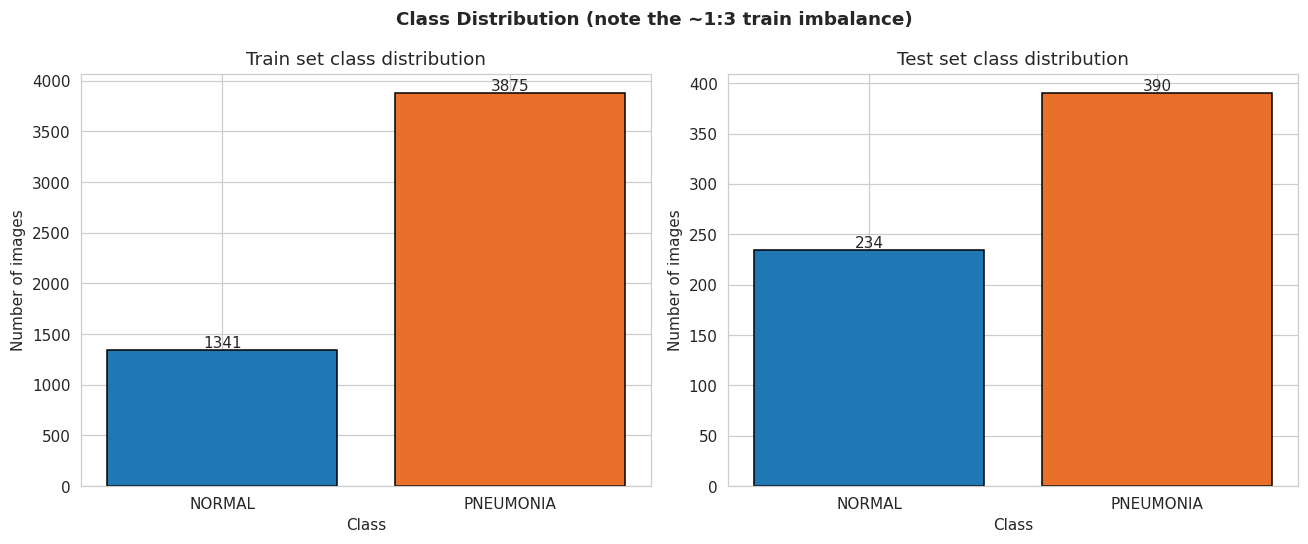

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, counts) in zip(axes, [("Train", train_counts), ("Test", test_counts)]):
    bars = ax.bar(list(counts.keys()), list(counts.values()),
                  color=[PALETTE[c] for c in counts.keys()], edgecolor="black")
    ax.set_title(f"{title} set class distribution")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of images")
    for b, v in zip(bars, counts.values()):
        ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha="center", va="bottom")

fig.suptitle("Class Distribution (note the ~1:3 train imbalance)", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "class_distribution.png"), bbox_inches="tight")
plt.show()

**Sample images.** A 2×4 grid (top row NORMAL, bottom row PNEUMONIA) gives a
feel for the task. Pneumonia X-rays typically show hazy white opacities in the
lung fields, whereas normal lungs look darker/clearer.

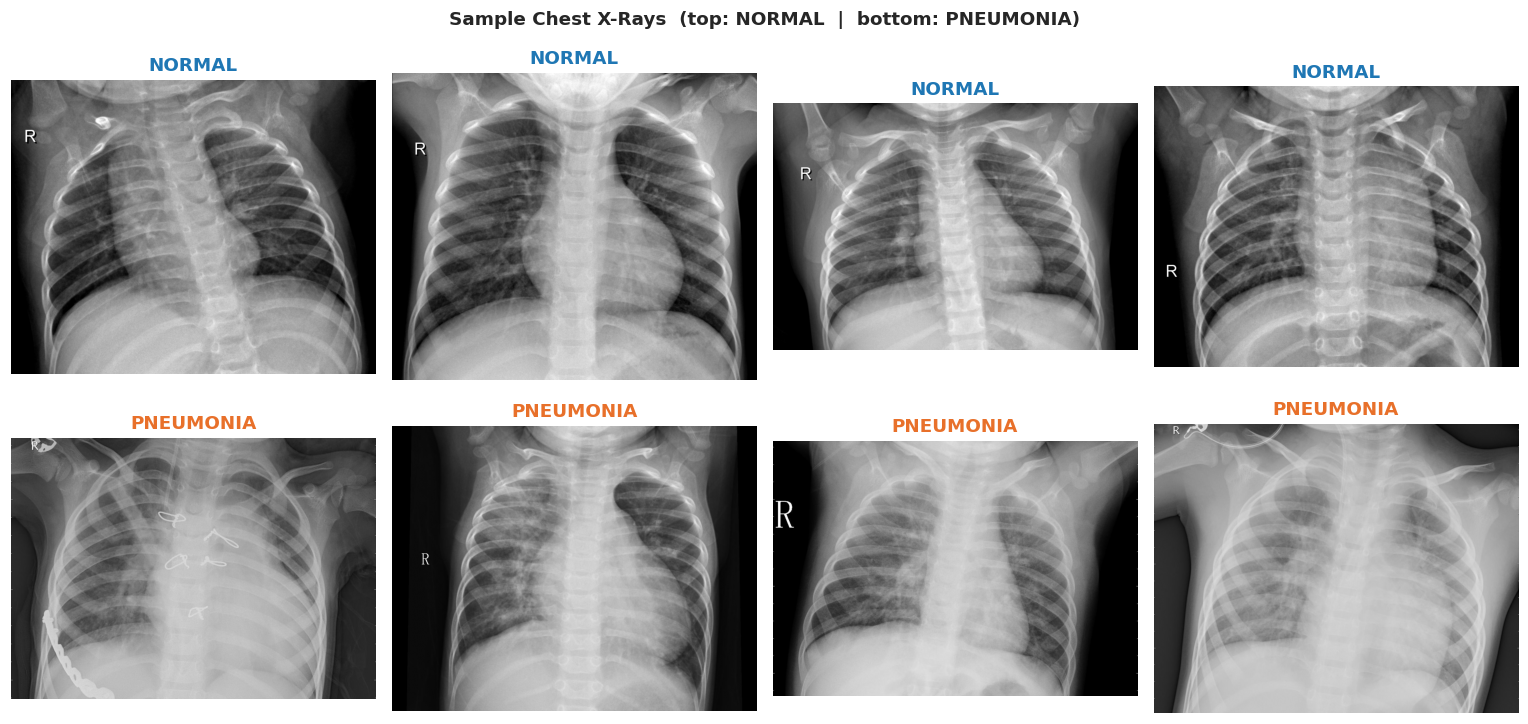

In [21]:
def sample_paths(split_dir, cls, n):
    """Return n reproducible sample paths for a class (seeded)."""
    paths = sorted(list_images(os.path.join(split_dir, cls)))
    return random.Random(SEED).sample(paths, n)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, cls in enumerate(CLASS_NAMES):
    for col, p in enumerate(sample_paths(TRAIN_DIR, cls, 4)):
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        ax = axes[row, col]
        ax.imshow(img, cmap="gray")
        ax.set_title(cls, color=PALETTE[cls], fontweight="bold")
        ax.axis("off")

fig.suptitle("Sample Chest X-Rays  (top: NORMAL  |  bottom: PNEUMONIA)", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "sample_images.png"), bbox_inches="tight")
plt.show()

**Size & intensity statistics.** Images come in varying resolutions, which is
why we resize everything to 224×224. Pixels live in `[0, 255]`, so we will
rescale by `1/255` in the data generators. (We sample a subset for speed.)

In [22]:
def image_statistics(split_dir, sample_per_class=150):
    """Mean dimensions + pixel statistics over a random per-class sample."""
    widths, heights, means, stds = [], [], [], []
    rng = random.Random(SEED)
    for cls in CLASS_NAMES:
        paths = list_images(os.path.join(split_dir, cls))
        for p in rng.sample(paths, min(sample_per_class, len(paths))):
            img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            h, w = img.shape
            widths.append(w); heights.append(h)
            means.append(img.mean()); stds.append(img.std())
    return map(np.array, (widths, heights, means, stds))

w, h, m, s = image_statistics(TRAIN_DIR)
print(f"Sampled {len(w)} training images")
print(f"Mean width : {w.mean():6.1f} px   (min {w.min()}, max {w.max()})")
print(f"Mean height: {h.mean():6.1f} px   (min {h.min()}, max {h.max()})")
print(f"Pixel mean : {m.mean():6.2f} / 255")
print(f"Pixel std  : {s.mean():6.2f}")
print("=> variable sizes -> resize to 224x224; pixels in [0,255] -> rescale 1/255.")

Sampled 300 training images
Mean width : 1439.7 px   (min 457, max 2916)
Mean height: 1098.8 px   (min 260, max 2663)
Pixel mean : 123.53 / 255
Pixel std  :  58.65
=> variable sizes -> resize to 224x224; pixels in [0,255] -> rescale 1/255.


## 3 · Data Preparation

Three important decisions are made here:

1. **Rebuild the validation split.** The original `val/` folder holds only 16
   images — statistically meaningless. Since `/kaggle/input/` is *read-only* we do
   **not** copy files; instead we collect `(filepath, label)` rows into a
   DataFrame and use a **stratified 80/20 split** of the training data, then feed
   the generators with `flow_from_dataframe`. The original `test/` is untouched.
2. **Conservative augmentation** (train only). Medical anatomy must stay upright,
   so we allow only a horizontal flip, ±10° rotation, small shifts and zoom — and
   **no** vertical flip, shear, or heavy color jitter. Val/test get rescale only.
3. **Class weights** to counter the 1:3 imbalance, applied in `model.fit`.

In [23]:
def build_dataframe(split_dir):
    """Build a shuffled DataFrame with columns [filepath, label]."""
    records = []
    for cls in CLASS_NAMES:
        for p in list_images(os.path.join(split_dir, cls)):
            records.append({"filepath": p, "label": cls})
    return (pd.DataFrame(records)
              .sample(frac=1.0, random_state=SEED)
              .reset_index(drop=True))

full_train_df = build_dataframe(TRAIN_DIR)
test_df       = build_dataframe(TEST_DIR)

# Stratified split keeps the NORMAL:PNEUMONIA ratio identical in train & val.
train_df, val_df = train_test_split(
    full_train_df,
    test_size=0.20,                       # ~20% held out for validation
    stratify=full_train_df["label"],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print("Final split sizes and class distribution:")
for name, d in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"  {name:11s}: {len(d):5d}  -> {d['label'].value_counts().to_dict()}")

Final split sizes and class distribution:
  Train      :  4172  -> {'PNEUMONIA': 3099, 'NORMAL': 1073}
  Validation :  1044  -> {'PNEUMONIA': 776, 'NORMAL': 268}
  Test       :   624  -> {'PNEUMONIA': 390, 'NORMAL': 234}


**Data generators.** Both models use the same 224×224 RGB, rescaled-to-`[0,1]`
inputs, so we build the generators once and reuse them. `class_mode="binary"` with
`classes=["NORMAL","PNEUMONIA"]` guarantees the mapping **NORMAL→0, PNEUMONIA→1**.
Validation and test use `shuffle=False` so predictions stay aligned with labels.

In [24]:
# Train-time augmentation (conservative — see rationale above).
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,        # pixels -> [0, 1]
    rotation_range=10,        # small tilt only; anatomy stays upright
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,     # left/right lungs roughly symmetric -> safe
    fill_mode="nearest",
)
# Validation & test: NO augmentation, only rescale.
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

common = dict(x_col="filepath", y_col="label", target_size=IMG_SIZE,
              color_mode="rgb", class_mode="binary",
              classes=CLASS_NAMES, batch_size=BATCH_SIZE)

train_gen = train_datagen.flow_from_dataframe(train_df, shuffle=True, seed=SEED, **common)
val_gen   = eval_datagen.flow_from_dataframe(val_df,   shuffle=False, **common)
test_gen  = eval_datagen.flow_from_dataframe(test_df,  shuffle=False, **common)

print("Class indices:", train_gen.class_indices)   # {'NORMAL': 0, 'PNEUMONIA': 1}

Found 4172 validated image filenames belonging to 2 classes.
Found 1044 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


**Class weights.** `compute_class_weight("balanced", ...)` assigns a larger
weight to the minority class (NORMAL), so each NORMAL mistake is penalized more
heavily during training. This discourages the trivial "predict PNEUMONIA always"
solution that the imbalance would otherwise encourage.

In [25]:
y_train_int = train_gen.classes                      # integer labels in feed order
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int,
)
class_weight = {int(k): float(v) for k, v in zip(np.unique(y_train_int), class_weights_arr)}
print("Class weights (NORMAL penalized more):", class_weight)

Class weights (NORMAL penalized more): {0: 1.9440820130475303, 1: 0.6731203614069055}


## 4 · Custom CNN (from scratch)

A compact 4-block convolutional network. Each block is
`Conv2D → BatchNorm → ReLU → MaxPool`, with the filter count doubling each block
(32 → 64 → 128 → 256). We use **GlobalAveragePooling** instead of a giant `Flatten`
to keep the parameter count low and reduce overfitting, then a `Dense(512)` head
with **Dropout(0.5)** and a single sigmoid output.

The model is compiled with **Adam(1e-4)**, `binary_crossentropy`, and the metrics
that matter clinically: **Recall** (primary), Precision, AUC, plus accuracy.

In [26]:
def build_custom_cnn(input_shape=IMG_SHAPE):
    """Build the 4-block custom CNN for binary classification.

    Conv -> BatchNorm -> ReLU ordering (BN before the non-linearity) stabilizes
    training. Filters double per block; GlobalAveragePooling keeps the head small.
    """
    inputs = Input(shape=input_shape, name="input")
    x = inputs
    for i, filters in enumerate([32, 64, 128, 256], start=1):   # doubling channels
        x = Conv2D(filters, (3, 3), padding="same", name=f"conv{i}")(x)
        x = BatchNormalization(name=f"bn{i}")(x)
        x = Activation("relu", name=f"relu{i}")(x)
        x = MaxPooling2D((2, 2), name=f"pool{i}")(x)
    x = GlobalAveragePooling2D(name="gap")(x)
    x = Dense(512, activation="relu", name="fc1")(x)
    x = Dropout(0.5, name="dropout")(x)                         # strong regularization
    outputs = Dense(1, activation="sigmoid", name="output")(x)  # P(PNEUMONIA)
    return Model(inputs, outputs, name="custom_cnn")


def compile_model(model, lr=1e-4):
    """Compile with Adam + clinically relevant metrics (Recall is primary).

    Metrics are explicitly named so callbacks can monitor 'val_recall'/'val_auc'
    consistently across both models.
    """
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.Recall(name="recall"),
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.AUC(name="auc")],
    )
    return model


custom_cnn = compile_model(build_custom_cnn(), lr=1e-4)   # 1e-4: stable for scratch training
custom_cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,433 (1.99 MB)

 Trainable params: 521,473 (1.99 MB)

 Non-trainable params: 960 (3.75 KB)

## 5 · Train the Custom CNN

Callbacks:
- **EarlyStopping** on `val_auc` (mode=max, patience=5, `restore_best_weights`).
  > Why `val_auc` and **not** `val_recall`? Recall has a *trivial maximum*: a model
  > that predicts PNEUMONIA for **every** image scores recall = 1.0 while being
  > useless (AUC ≈ 0.5). Monitoring `val_recall` makes EarlyStopping lock onto that
  > degenerate epoch and discard genuinely good ones. **AUC is threshold-free and
  > cannot be gamed this way**, so it selects the best discriminator. Recall stays
  > our *reported* clinical metric and can be raised afterwards by tuning the
  > decision threshold (a far safer lever than model selection).
- **ReduceLROnPlateau** on `val_loss` (factor 0.5, patience 3) — anneal the LR
  when validation loss stalls.
- **ModelCheckpoint** — save the best (`val_auc`) model to
  `/kaggle/working/best_custom_cnn.keras`; we reload it before evaluation.

`class_weight` is applied to handle the imbalance. We cap training at 30 epochs;
EarlyStopping typically stops earlier.

In [27]:
def make_callbacks(checkpoint_path):
    """Build the shared callback list (used by both the custom CNN and VGG16).

    We monitor **val_auc** for EarlyStopping/ModelCheckpoint, NOT val_recall.
    Recall has a trivial maximum: predicting PNEUMONIA for everything gives
    recall = 1.0 while being useless (AUC ~ 0.5). Monitoring val_recall would lock
    onto that degenerate epoch and restore the worst model. AUC is threshold-free
    and cannot be gamed that way, so it picks the genuinely best discriminator.
    Recall remains our reported metric and is tuned later via the threshold.
    """
    return [
        EarlyStopping(monitor="val_auc", mode="max", patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor="val_auc", mode="max",
                        save_best_only=True, verbose=1),
    ]

CUSTOM_CKPT = os.path.join(OUTPUT_DIR, "best_custom_cnn.keras")
EPOCHS = 30   # upper bound; EarlyStopping usually halts sooner

history_custom = custom_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight,            # <-- handles the ~1:3 imbalance
    callbacks=make_callbacks(CUSTOM_CKPT),
    verbose=1,
)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.7907 - auc: 0.8616 - loss: 0.4451 - precision: 0.9207 - recall: 0.7885
Epoch 1: val_auc improved from None to 0.45747, saving model to /kaggle/working/best_custom_cnn.keras

Epoch 1: finished saving model to /kaggle/working/best_custom_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 90s 638ms/step - accuracy: 0.8471 - auc: 0.9270 - loss: 0.3416 - precision: 0.9559 - recall: 0.8325 - val_accuracy: 0.7433 - val_auc: 0.4575 - val_loss: 1.2369 - val_precision: 0.7433 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.8873 - auc: 0.9506 - loss: 0.2749 - precision: 0.9755 - recall: 0.8673
Epoch 2: val_auc improved from 0.45747 to 0.50000, saving model to /kaggle/working/best_custom_cnn.keras

Epoch 2: finished saving model to /kaggle/working/best_custom_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 79s 606ms/step - accuracy: 0.8948 - auc: 0.9581 - loss: 0.2480 - precision: 0.

## 6 · Training Curves — Custom CNN

Train vs. validation **accuracy** (left) and **loss** (right). A growing gap
between the two curves indicates overfitting; converging curves indicate healthy
learning.

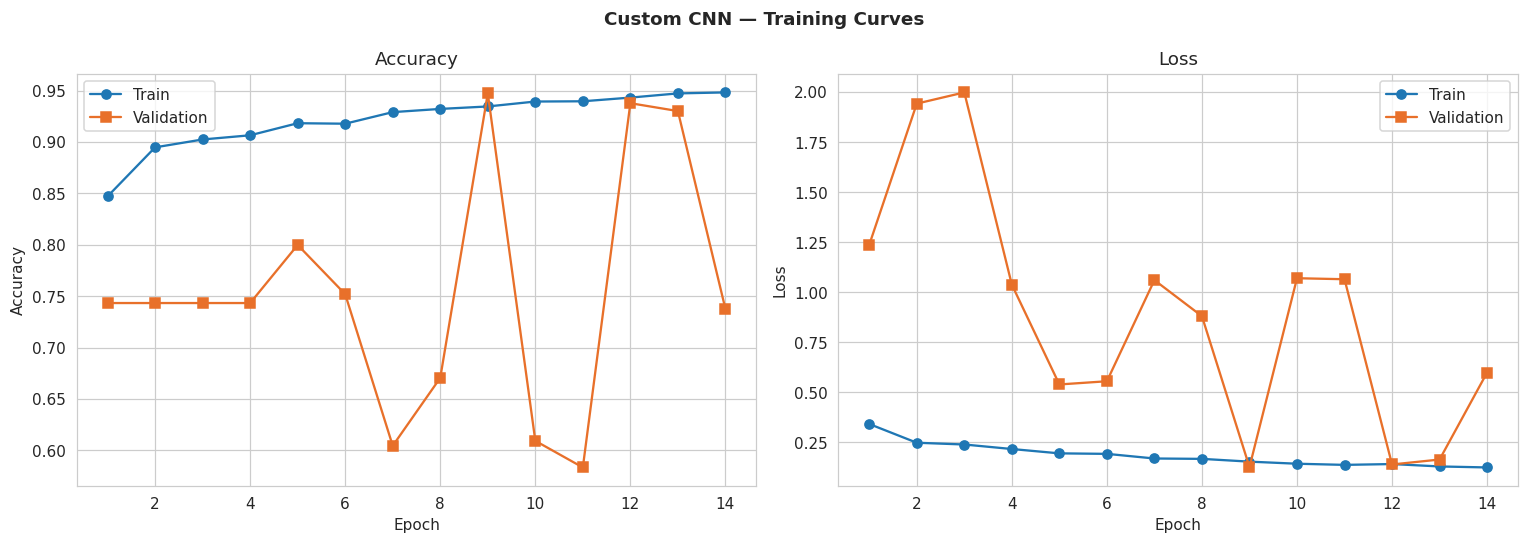

In [28]:
def plot_training_curves(history_dict, title, save_path):
    """Plot train vs. validation accuracy and loss side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_r = range(1, len(history_dict["loss"]) + 1)

    axes[0].plot(epochs_r, history_dict["accuracy"], "o-", color=COLOR_NORMAL, label="Train")
    axes[0].plot(epochs_r, history_dict["val_accuracy"], "s-", color=COLOR_PNEUMONIA, label="Validation")
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy"); axes[0].legend()

    axes[1].plot(epochs_r, history_dict["loss"], "o-", color=COLOR_NORMAL, label="Train")
    axes[1].plot(epochs_r, history_dict["val_loss"], "s-", color=COLOR_PNEUMONIA, label="Validation")
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss"); axes[1].legend()

    fig.suptitle(title, fontweight="bold")
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_training_curves(history_custom.history, "Custom CNN — Training Curves",
                     os.path.join(FIG_DIR, "custom_cnn_training_curves.png"))

## 7 · Transfer Learning — VGG16

We reuse **VGG16 pretrained on ImageNet** (`include_top=False`) as a feature
extractor and attach a small custom head
(`GlobalAveragePooling → Dense(256) → Dropout(0.4) → Dense(1, sigmoid)`).

Two-phase training:
1. **Feature extraction** — freeze the entire VGG16 base and train only the head
   for 10 epochs at `lr=1e-4`.
2. **Fine-tuning** — unfreeze the **last 4 layers** of the base, recompile with a
   much smaller `lr=1e-5` (so we gently adapt pretrained filters without
   destroying them), and train for 10 more epochs.

The best model (by `val_auc`) is saved to `/kaggle/working/best_vgg16.keras`.

In [29]:
def build_vgg16():
    """VGG16 (ImageNet) backbone + custom binary head; base frozen initially."""
    base = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
    base.trainable = False                              # phase 1: feature extraction
    inputs = Input(shape=IMG_SHAPE, name="input")
    x = base(inputs, training=False)                    # BN-free backbone, keep frozen
    x = GlobalAveragePooling2D(name="vgg_gap")(x)
    x = Dense(256, activation="relu", name="vgg_fc1")(x)
    x = Dropout(0.4, name="vgg_dropout")(x)
    outputs = Dense(1, activation="sigmoid", name="vgg_output")(x)
    return Model(inputs, outputs, name="vgg16_transfer"), base

vgg_model, vgg_base = build_vgg16()
vgg_model = compile_model(vgg_model, lr=1e-4)
vgg_model.summary()

Model: "vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_gap                         │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_fc1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_dropout (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_output (Dense)              │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

**Phase 1 — feature extraction** (frozen base).

In [30]:
VGG_CKPT = os.path.join(OUTPUT_DIR, "best_vgg16.keras")
EPOCHS_FROZEN = 10

print("Phase 1: feature extraction (VGG16 base frozen)")
history_vgg1 = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    class_weight=class_weight,
    callbacks=make_callbacks(VGG_CKPT),
    verbose=1,
)

Phase 1: feature extraction (VGG16 base frozen)
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.5606 - auc: 0.6254 - loss: 0.6748 - precision: 0.8109 - recall: 0.5194
Epoch 1: val_auc improved from None to 0.93915, saving model to /kaggle/working/best_vgg16.keras

Epoch 1: finished saving model to /kaggle/working/best_vgg16.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 643ms/step - accuracy: 0.6462 - auc: 0.7134 - loss: 0.6243 - precision: 0.8490 - recall: 0.6370 - val_accuracy: 0.8247 - val_auc: 0.9392 - val_loss: 0.5329 - val_precision: 0.9821 - val_recall: 0.7784 - learning_rate: 1.0000e-04
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.7819 - auc: 0.8648 - loss: 0.5070 - precision: 0.9197 - recall: 0.7800
Epoch 2: val_auc improved from 0.93915 to 0.94723, saving model to /kaggle/working/best_vgg16.keras

Epoch 2: finished saving model to /kaggle/working/best_vgg16.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 619ms/step - accuracy: 0.8003 - auc: 0.8886 - 

**Phase 2 — fine-tuning** the last 4 base layers at a 10× smaller learning rate.

In [31]:
# Unfreeze only the last 4 layers of the VGG16 base.
vgg_base.trainable = True
for layer in vgg_base.layers[:-4]:
    layer.trainable = False
print("Trainable VGG16 base layers:", [l.name for l in vgg_base.layers if l.trainable])

# Recompile is REQUIRED after changing trainability; use a tiny LR for fine-tuning.
vgg_model = compile_model(vgg_model, lr=1e-5)

EPOCHS_FINETUNE = 10
print("Phase 2: fine-tuning (last 4 conv layers, lr=1e-5)")
history_vgg2 = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    class_weight=class_weight,
    callbacks=make_callbacks(VGG_CKPT),
    verbose=1,
)

Trainable VGG16 base layers: ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']
Phase 2: fine-tuning (last 4 conv layers, lr=1e-5)
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.9142 - auc: 0.9721 - loss: 0.2098 - precision: 0.9799 - recall: 0.9018
Epoch 1: val_auc improved from None to 0.99136, saving model to /kaggle/working/best_vgg16.keras

Epoch 1: finished saving model to /kaggle/working/best_vgg16.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 90s 650ms/step - accuracy: 0.9298 - auc: 0.9787 - loss: 0.1813 - precision: 0.9825 - recall: 0.9219 - val_accuracy: 0.9157 - val_auc: 0.9914 - val_loss: 0.2035 - val_precision: 0.9943 - val_recall: 0.8918 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.9498 - auc: 0.9867 - loss: 0.1420 - precision: 0.9867 - recall: 0.9451
Epoch 2: val_auc improved from 0.99136 to 0.99392, saving model to /kaggle/working/best_vgg16.keras

Epoch 2: finished saving model to /kaggle/working/

**Combined training curves** across both phases.

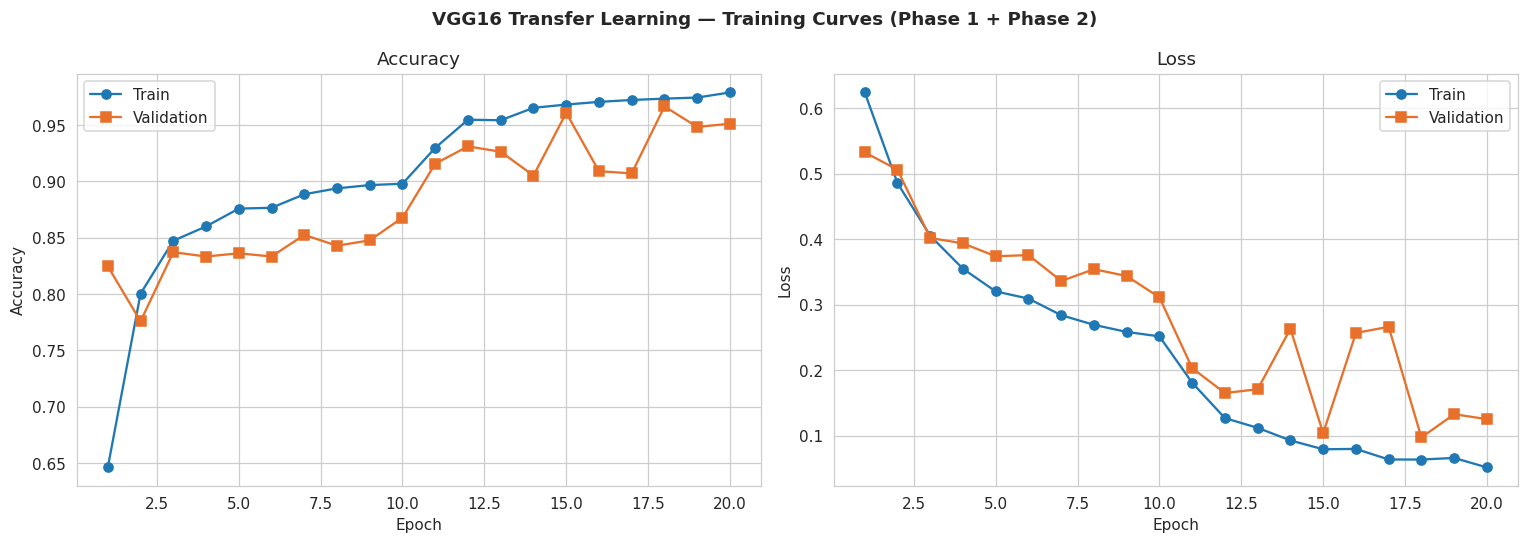

In [32]:
def merge_histories(*hists):
    """Concatenate several Keras history dicts for one continuous plot."""
    merged = {}
    for h in hists:
        for k, v in h.items():
            merged.setdefault(k, []).extend(v)
    return merged

history_vgg = merge_histories(history_vgg1.history, history_vgg2.history)
plot_training_curves(
    history_vgg,
    "VGG16 Transfer Learning — Training Curves (Phase 1 + Phase 2)",
    os.path.join(FIG_DIR, "vgg16_training_curves.png"),
)

## 8 · Evaluation — Custom CNN

We **reload the best saved weights** (not the last epoch), predict on the held-out
`test/` set, and report the full picture: a `sklearn` classification report, a
styled confusion-matrix heatmap, and the headline metrics (Accuracy, Precision,
**Recall**, F1, AUC). A decision threshold of **0.5** maps the sigmoid output to a
class.

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 514ms/step

===== Custom CNN -- Test Classification Report =====
              precision    recall  f1-score   support

      NORMAL     0.9848    0.2778    0.4333       234
   PNEUMONIA     0.6971    0.9974    0.8207       390

    accuracy                         0.7276       624
   macro avg     0.8410    0.6376    0.6270       624
weighted avg     0.8050    0.7276    0.6754       624

Accuracy : 0.7276
Precision: 0.6971
Recall   : 0.9974   <-- primary clinical metric (sensitivity)
F1-score : 0.8207
AUC      : 0.9295


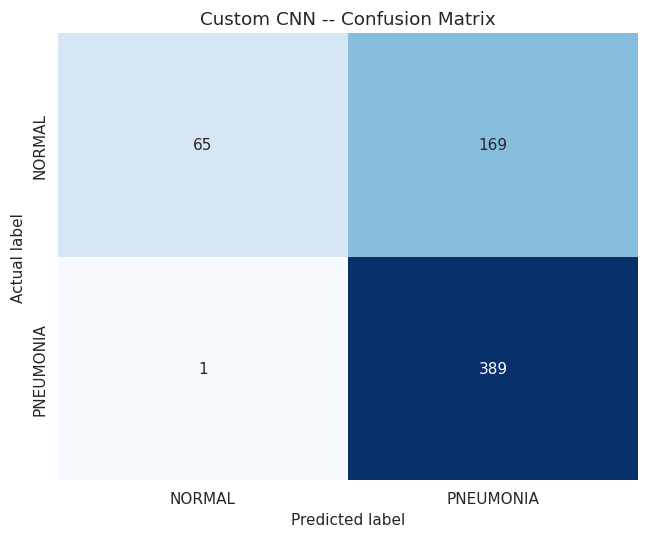

In [33]:
def evaluate_model(checkpoint_path, generator, model_name, cm_save_path):
    """Reload best weights, predict on the test set, print metrics, plot the CM.

    Returns a dict of scalar metrics plus raw arrays (for comparison / Grad-CAM).
    """
    model = load_model(checkpoint_path)          # best weights, not last epoch
    generator.reset()                            # ensure predictions align with labels
    y_prob = model.predict(generator, verbose=1).ravel()
    y_pred = (y_prob >= 0.5).astype(int)         # 0.5 decision threshold
    y_true = generator.classes

    print(f"\n===== {model_name} -- Test Classification Report =====")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)       # pos_label=1 (PNEUMONIA)
    rec  = recall_score(y_true, y_pred)          # sensitivity for PNEUMONIA
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}   <-- primary clinical metric (sensitivity)")
    print(f"F1-score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("Actual label")
    ax.set_title(f"{model_name} -- Confusion Matrix")
    fig.tight_layout()
    fig.savefig(cm_save_path, bbox_inches="tight")
    plt.show()

    return {"Model": model_name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1": f1, "AUC": auc,
            "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob}

custom_results = evaluate_model(
    CUSTOM_CKPT, test_gen, "Custom CNN",
    os.path.join(FIG_DIR, "custom_cnn_confusion_matrix.png"))

## 9 · Evaluation — VGG16

The exact same evaluation procedure, applied to the best saved VGG16 model.

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 440ms/step

===== VGG16 -- Test Classification Report =====
              precision    recall  f1-score   support

      NORMAL     0.9617    0.7521    0.8441       234
   PNEUMONIA     0.8685    0.9821    0.9218       390

    accuracy                         0.8958       624
   macro avg     0.9151    0.8671    0.8830       624
weighted avg     0.9035    0.8958    0.8927       624

Accuracy : 0.8958
Precision: 0.8685
Recall   : 0.9821   <-- primary clinical metric (sensitivity)
F1-score : 0.9218
AUC      : 0.9697


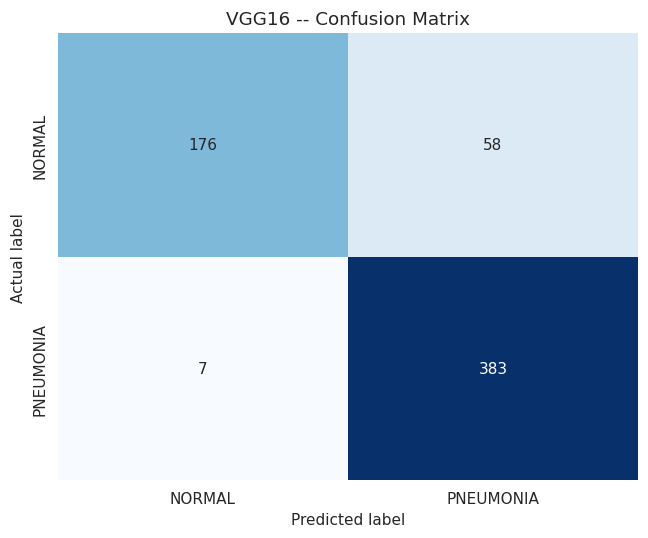

In [34]:
vgg_results = evaluate_model(
    VGG_CKPT, test_gen, "VGG16",
    os.path.join(FIG_DIR, "vgg16_confusion_matrix.png"))

## 10 · Model Comparison

A side-by-side table and a grouped bar chart of all five metrics. Recall is the
one to watch for this clinical task, with F1 as the balanced secondary metric.

            Accuracy  Precision  Recall      F1     AUC
Model                                                  
Custom CNN    0.7276     0.6971  0.9974  0.8207  0.9295
VGG16         0.8958     0.8685  0.9821  0.9218  0.9697


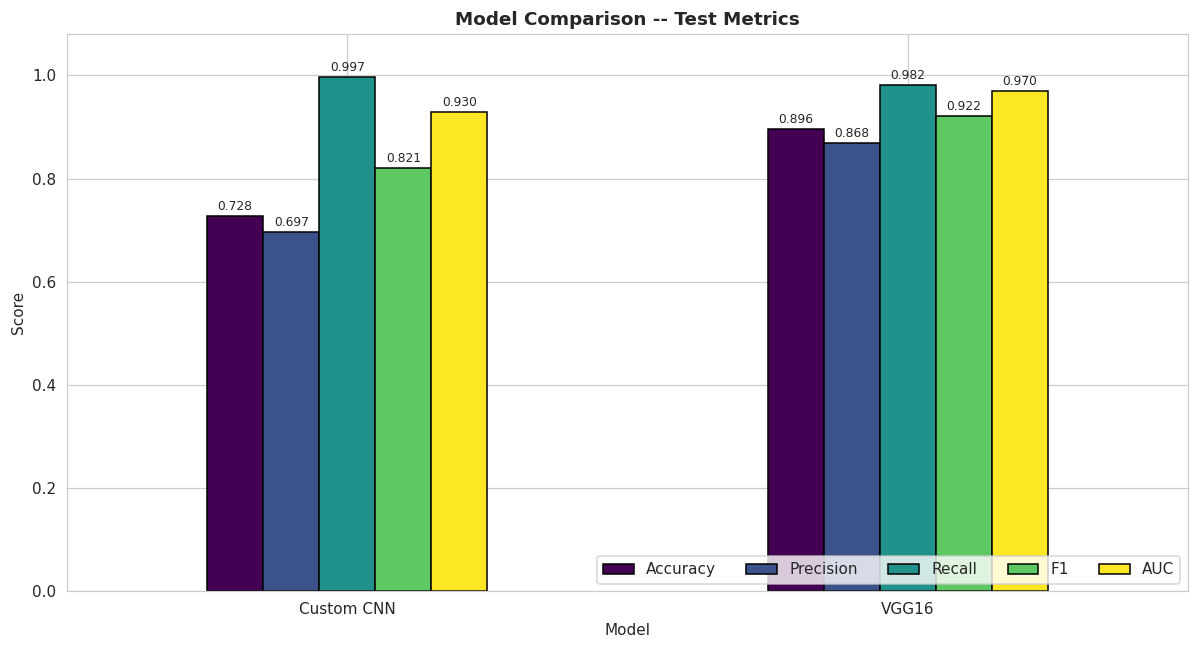

In [35]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
comparison_df = pd.DataFrame(
    [{k: r[k] for k in ["Model"] + metric_cols} for r in (custom_results, vgg_results)]
).set_index("Model")

print(comparison_df.round(4))

ax = comparison_df.plot(kind="bar", figsize=(11, 6), rot=0,
                        colormap="viridis", edgecolor="black")
ax.set_title("Model Comparison -- Test Metrics", fontweight="bold")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.08)
ax.legend(loc="lower right", ncol=len(metric_cols))
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "model_comparison.png"), bbox_inches="tight")
plt.show()

## 11 · (Bonus) Grad-CAM Visualization

**Grad-CAM** highlights the image regions that most influenced the prediction, by
weighting the last convolutional feature maps with the gradient of the predicted
score. For a trustworthy pneumonia model, the heatmaps should focus on the **lung
fields**, not on borders, text, or hardware.

We run it on the **better-performing model**, chosen by **F1 (with AUC as a
tie-breaker)** — a balanced criterion, *not* recall alone (recall by itself favours a
model that simply over-predicts PNEUMONIA). We show 2 correct and 2 misclassified
test cases. The helper below works for both a flat CNN *and* a model with a nested
backbone (VGG16): in the nested case it re-wires the shared layers into one flat
graph so the last conv activations are reachable.

In [ ]:
def build_grad_model(model):
    """Return a model mapping image -> (last_conv_activation, prediction).

    Handles a flat CNN (Conv2D at the top level) and a transfer model whose conv
    backbone is a nested sub-Model (e.g. VGG16). For the nested case the layers
    are re-applied into a single flat graph (weights are shared, not copied).

    We use `model.input` (the single input tensor), not `model.inputs` (a list),
    so that calling the grad model with one image tensor matches the expected
    input structure under Keras 3 (avoids a spurious structure-mismatch warning).
    """
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):                 # flat CNN
            return Model(model.input, [layer.output, model.output])
        if isinstance(layer, tf.keras.Model):                         # nested backbone
            idx = model.layers.index(layer)
            inp = model.input
            x = inp
            conv_tensor = None
            for sub in layer.layers:
                if isinstance(sub, tf.keras.layers.InputLayer):
                    continue
                x = sub(x)
                if isinstance(sub, tf.keras.layers.Conv2D):
                    conv_tensor = x                                   # last conv activation
            for head in model.layers[idx + 1:]:                       # re-apply the head
                x = head(x)
            return Model(inp, [conv_tensor, x])
    raise ValueError("No Conv2D layer found for Grad-CAM.")


def make_gradcam_heatmap(img_array, grad_model):
    """Compute a normalized Grad-CAM heatmap for one preprocessed image (1,H,W,3)."""
    img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array, training=False)
        score = preds[:, 0]                              # single sigmoid output
    grads = tape.gradient(score, conv_out)               # d(score)/d(activations)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))       # channel importances
    conv_out = conv_out[0]
    heatmap = tf.squeeze(conv_out @ pooled[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0)                     # keep positive evidence
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)  # -> [0, 1]
    return heatmap.numpy()


def overlay_heatmap(img_path, heatmap, alpha=0.4):
    """Overlay a JET-colored heatmap on the (resized) original image."""
    img = cv2.cvtColor(cv2.resize(cv2.imread(img_path), IMG_SIZE), cv2.COLOR_BGR2RGB)
    hm = np.uint8(255 * cv2.resize(heatmap, IMG_SIZE))
    hm = cv2.cvtColor(cv2.applyColorMap(hm, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    overlay = np.uint8(img * (1 - alpha) + hm * alpha)
    return img, overlay

In [ ]:
# Pick the better model by F1 (balanced precision/recall), AUC as tie-breaker.
# NOTE: we do NOT select by recall alone -- a model that simply over-predicts
# PNEUMONIA gets near-perfect recall while being the worse classifier, so recall
# would point Grad-CAM at the weaker model. F1/AUC pick the genuinely better one.
best = (custom_results
        if (custom_results["F1"], custom_results["AUC"])
           >= (vgg_results["F1"], vgg_results["AUC"])
        else vgg_results)
best_ckpt = CUSTOM_CKPT if best["Model"] == "Custom CNN" else VGG_CKPT
best_model = load_model(best_ckpt)
print("Grad-CAM target model:", best["Model"])

grad_model = build_grad_model(best_model)

# Choose 2 correctly classified + 2 misclassified test images (reproducibly).
y_true, y_pred = best["y_true"], best["y_pred"]
correct_idx   = np.where(y_true == y_pred)[0]
incorrect_idx = np.where(y_true != y_pred)[0]
rng = np.random.default_rng(SEED)
sel_correct   = rng.choice(correct_idx,   size=min(2, len(correct_idx)),   replace=False)
sel_incorrect = (rng.choice(incorrect_idx, size=min(2, len(incorrect_idx)), replace=False)
                 if len(incorrect_idx) else np.array([], dtype=int))
selected = list(sel_correct) + list(sel_incorrect)

fig, axes = plt.subplots(len(selected), 2, figsize=(8, 4 * len(selected)))
if len(selected) == 1:
    axes = axes[np.newaxis, :]
for row, i in enumerate(selected):
    path = test_df.iloc[i]["filepath"]
    img = tf.keras.preprocessing.image.load_img(path, target_size=IMG_SIZE, color_mode="rgb")
    arr = np.expand_dims(tf.keras.preprocessing.image.img_to_array(img) / 255.0, 0)
    heatmap = make_gradcam_heatmap(arr, grad_model)
    original, overlay = overlay_heatmap(path, heatmap)

    truth, pred = CLASS_NAMES[y_true[i]], CLASS_NAMES[y_pred[i]]
    verdict = "correct" if y_true[i] == y_pred[i] else "MISCLASSIFIED"
    axes[row, 0].imshow(original); axes[row, 0].axis("off")
    axes[row, 0].set_title(f"Original\nTrue = {truth}", color=PALETTE[truth])
    axes[row, 1].imshow(overlay); axes[row, 1].axis("off")
    axes[row, 1].set_title(f"Grad-CAM ({verdict})\nPred = {pred}", color=PALETTE[pred])

fig.suptitle(f"Grad-CAM -- {best['Model']} (last convolutional layer)", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "gradcam_visualization.png"), bbox_inches="tight")
plt.show()

## 12 · Summary & Conclusions

**Which model performed better and why.** On the held-out `test/` set the
**VGG16 transfer-learning model clearly wins**: accuracy **0.896**, F1 **0.922**,
AUC **0.970**, recall **0.982** — versus the custom CNN's accuracy 0.728, F1 0.821,
AUC 0.930 (recall 0.997). VGG16's ImageNet-pretrained filters already encode generic
edge/texture detectors, so it generalises better than a network trained from scratch
on only ~5k images. The custom CNN reaches the highest *recall*, but only because at
a fixed 0.5 threshold it **over-predicts PNEUMONIA**; its precision (0.697) and
accuracy (0.728) are much lower. Its AUC of 0.930 shows it *can* discriminate — the
weakness is decision-threshold calibration, not a failure to learn. The Grad-CAM
target is therefore selected by **F1 / AUC**, not by recall alone.

**What the confusion matrices tell us clinically.** The bottom-left cell —
**False Negatives** (true PNEUMONIA predicted NORMAL) — is the dangerous one: a sick
patient sent home. **VGG16** misses only **7 of 390** pneumonia cases while raising
**58 false alarms** among 234 healthy patients (specificity ≈ 75 %) — a sensible
screening trade-off. The **custom CNN** misses just **1 of 390** pneumonias but flags
**169 of 234** healthy patients as sick (specificity ≈ 28 %), which would overwhelm
clinicians with false positives. Both designs deliberately push errors away from
False Negatives and toward False Positives via **class weighting** — the right
direction for screening — but only VGG16 keeps the false-positive rate acceptable.

**Limitations.**
- **Single-source dataset** (one hospital/pediatric population): models can latch
  onto scanner/text artifacts rather than pathology — the Grad-CAM check helps
  catch this but is not proof of clinical validity.
- **Validation came from the train distribution**, so val metrics are optimistic; the
  wide validation swings and the val→test gap (val ≈ 0.95 vs test ≈ 0.90) reflect
  this. The untouched `test/` set is the honest estimate.
- We used a plain `1/255` rescale for VGG16 instead of its native
  `preprocess_input` (caffe-style mean subtraction). This keeps both models on
  identical generators but slightly underuses the pretrained weights.
- **Model selection & threshold:** early stopping and checkpointing monitor
  **`val_auc`** (threshold-free), because recall alone has a trivial maximum (an
  "always-PNEUMONIA" model scores recall 1.0). Even so, the fixed **0.5 threshold** is
  arbitrary and is the main reason the custom CNN's specificity collapses on test.

**Potential improvements.**
- Use VGG16/ResNet `preprocess_input` and try stronger backbones
  (EfficientNet, DenseNet121) or progressive unfreezing.
- **Tune the decision threshold** on validation to hit a target sensitivity
  (e.g. ≥ 0.97), and report a full ROC/PR curve.
- Try **focal loss** or oversampling as alternatives/complements to class weights.
- **k-fold cross-validation** and external test sets for a robust estimate.
- Test-time augmentation and model **ensembling** for a final accuracy bump.
- Calibrate probabilities (Platt/temperature scaling) so outputs are trustworthy.